In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm

# -------------------------
# Load dataset
# -------------------------

#We load the salary dataset and inspect basic structure: number of rows/columns, data types, and missingness proportions
df = pd.read_csv("salary_dataset.csv")

print(df.shape)
display(df.head())
print(df.dtypes)
print(df.isna().mean().sort_values(ascending=False).head(15))


(12000, 11)


,age,gender,education_level,years_experience,job_title,performance_score,industry,city,previous_companies,remote_worker,salary
0,30,Male,Bachelors,5.9,JobRole_5,3.0,Tech,Dallas,5,Yes,93292.58
1,37,Female,PhD,17.9,JobRole_13,5.0,Tech,Austin,1,Yes,138714.55
2,42,Female,Bachelors,19.1,JobRole_14,4.4,Finance,Austin,2,No,93073.72
3,30,Female,Bachelors,7.7,JobRole_15,3.8,Finance,Denver,1,No,83050.31
4,42,Male,Bachelors,23.2,JobRole_13,4.1,Tech,New York,3,No,160544.79


age                     int64
gender                 object
education_level        object
years_experience      float64
job_title              object
performance_score     float64
industry               object
city                   object
previous_companies      int64
remote_worker          object
salary                float64
dtype: object
performance_score     0.021167
years_experience      0.011000
education_level       0.009583
city                  0.005000
age                   0.000000
gender                0.000000
job_title             0.000000
industry              0.000000
previous_companies    0.000000
remote_worker         0.000000
salary                0.000000
dtype: float64


In [ ]:

#Univariate plots show the distribution of numeric variables. Salary typically exhibits skew (long right tail), which can impact OLS assumptions
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

display(df[num_cols].describe().T)

for c in cat_cols:
    print("\n", c)
    print(df[c].value_counts(dropna=False).head(10))


Numeric columns: ['age', 'years_experience', 'performance_score', 'previous_companies', 'salary']
Categorical columns: ['gender', 'education_level', 'job_title', 'industry', 'city', 'remote_worker']


,count,mean,std,min,25%,50%,75%,max
age,12000.0,35.693083,7.741977,21.00,30.0000,36.00,41.00,65.000000
years_experience,11868.0,15.731530,8.204885,0.00,9.9000,15.55,21.30,45.000000
performance_score,11746.0,3.752103,0.775138,1.00,3.2000,3.80,4.30,5.000000
previous_companies,12000.0,1.984417,1.397797,0.00,1.0000,2.00,3.00,12.000000
salary,12000.0,105862.030433,28250.776445,31728.08,88133.9225,103028.19,120510.67,497044.771908



 gender
gender
Male      6691
Female    5094
Other      215
Name: count, dtype: int64

 education_level
education_level
Bachelors     6603
Masters       2904
HighSchool    1810
PhD            568
NaN            115
Name: count, dtype: int64

 job_title
job_title
JobRole_10    837
JobRole_8     829
JobRole_13    823
JobRole_7     823
JobRole_9     816
JobRole_11    813
JobRole_14    807
JobRole_15    800
JobRole_4     798
JobRole_6     797
Name: count, dtype: int64

 industry
industry
Tech          5367
Finance       2430
Healthcare    2404
Retail        1799
Name: count, dtype: int64

 city
city
Miami            1032
Boston           1027
Dallas           1024
San Francisco    1023
Austin           1013
Los Angeles      1010
Raleigh           998
Seattle           981
New York          971
Chicago           971
Name: count, dtype: int64

 remote_worker
remote_worker
No     6850
Yes    5150
Name: count, dtype: int64


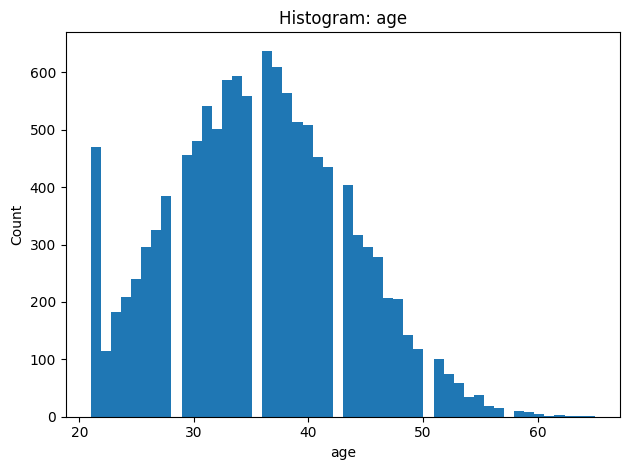

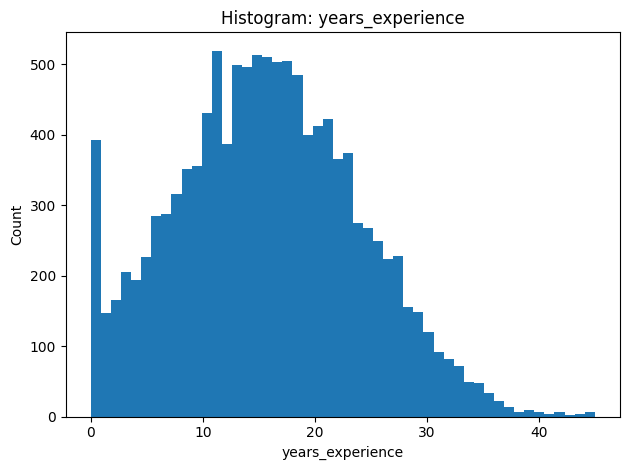

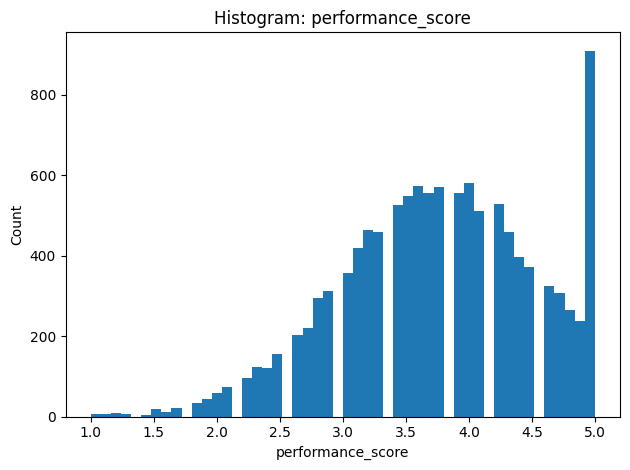

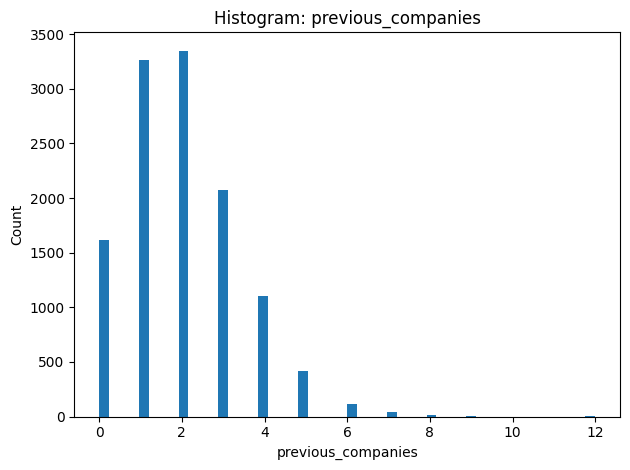

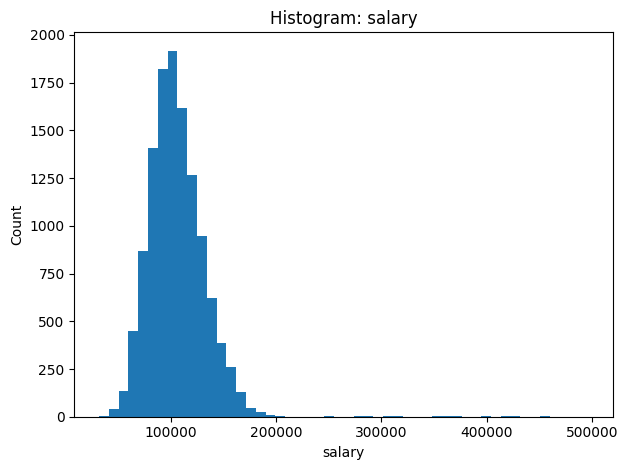

In [5]:
# Histograms for numeric columns
for c in num_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=50)
    plt.title(f"Histogram: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


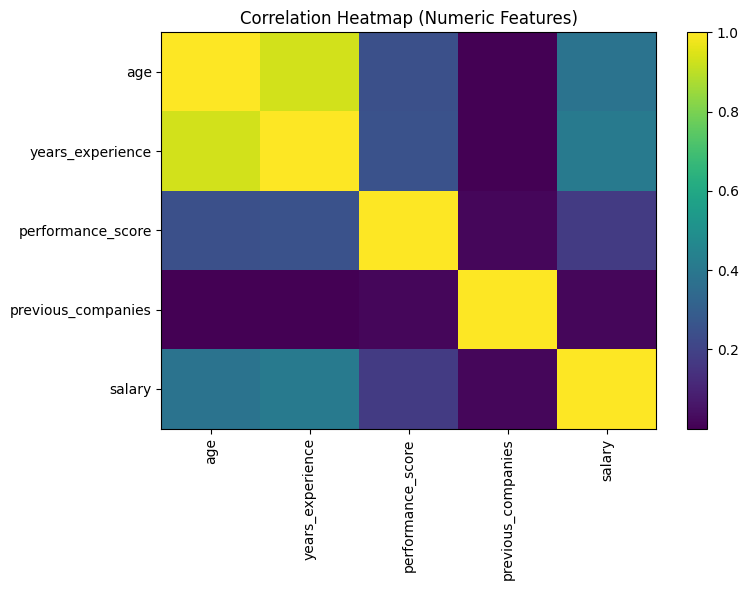

In [ ]:
#Correlation heatmap helps identify linear relationships with salary (e.g., years_experience usually correlates strongly), and checks multicollinearity risk among numeric predictors.
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


<Figure size 700x400 with 0 Axes>

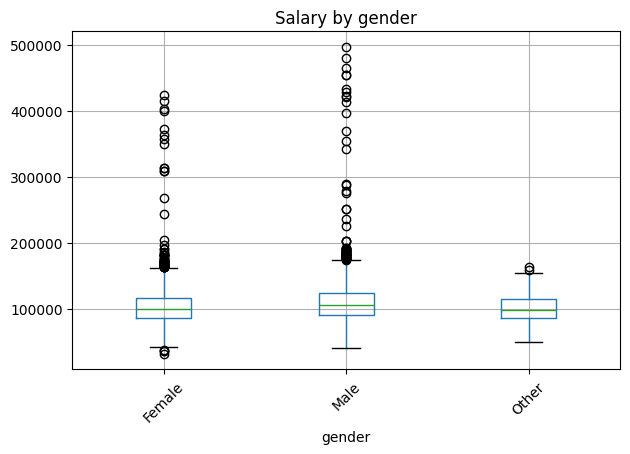

<Figure size 700x400 with 0 Axes>

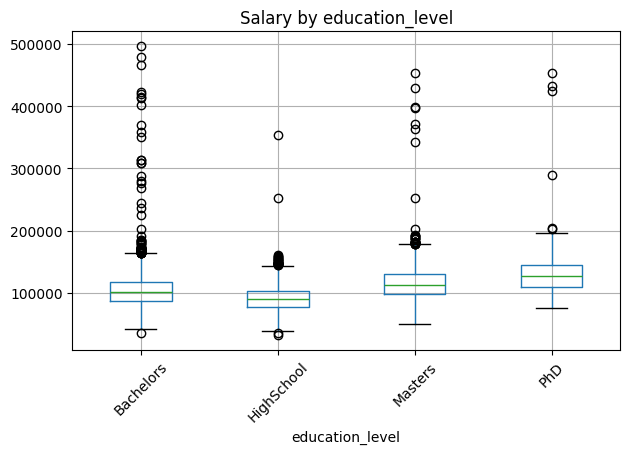

<Figure size 700x400 with 0 Axes>

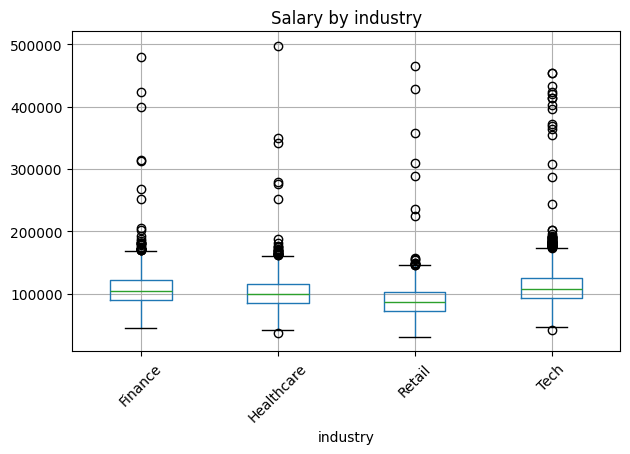

<Figure size 700x400 with 0 Axes>

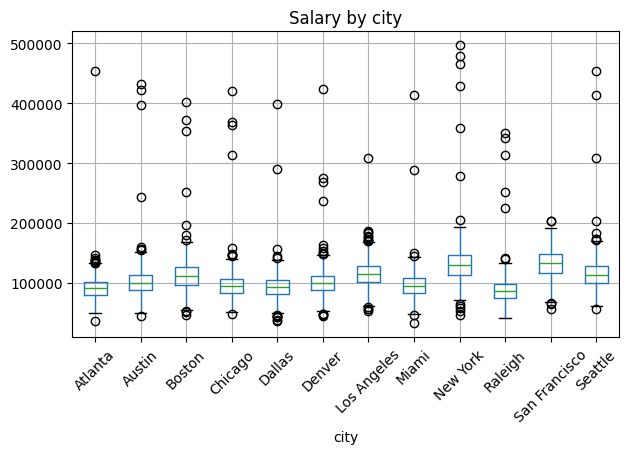

<Figure size 700x400 with 0 Axes>

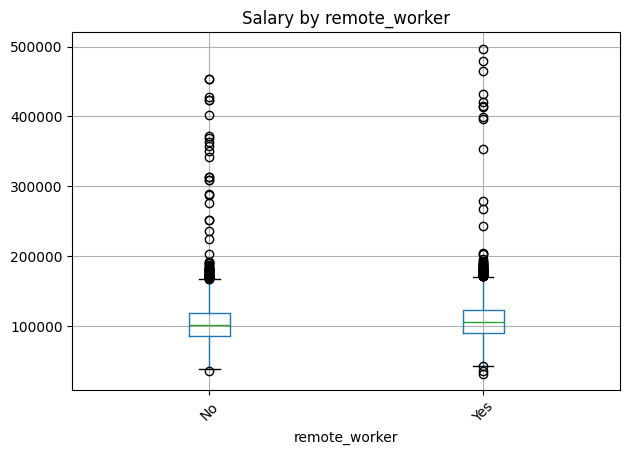

In [ ]:
#Group-wise boxplots reveal differences in salary distributions across demographic and job-related categories, motivating later fairness diagnostics.

group_cols = ["gender", "education_level", "industry", "city", "remote_worker"]

for g in group_cols:
    plt.figure(figsize=(7,4))
    df.boxplot(column="salary", by=g)
    plt.title(f"Salary by {g}")
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
#We impute numeric features using the median (robust to outliers) and categorical features using the most frequent category, preserving sample size and stability.
missing_pct = df.isna().mean().sort_values(ascending=False)
display(missing_pct[missing_pct > 0])


performance_score    0.021167
years_experience     0.011000
education_level      0.009583
city                 0.005000
dtype: float64

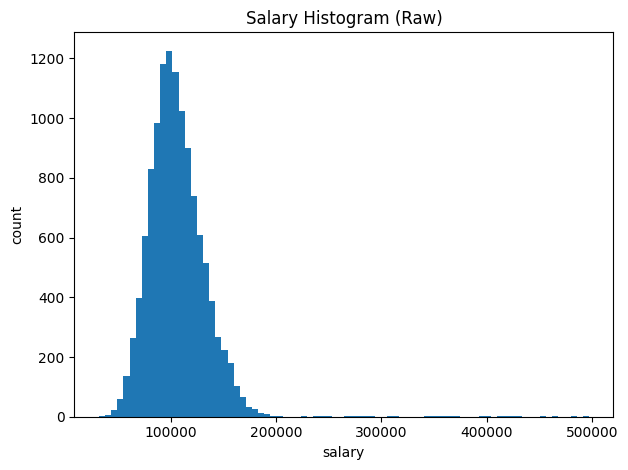

0.01     56635.3244
0.05     68355.3755
0.50    103028.1900
0.95    150414.3580
0.99    171449.9660
Name: salary, dtype: float64


In [ ]:
#Salary typically has heavy tails. Instead of deleting outliers (which can bias the dataset), we use robust imputation and later diagnose model fit via residual plots. (Optional extensions: log-transform salary or robust regression.)
plt.figure()
plt.hist(df["salary"], bins=80)
plt.title("Salary Histogram (Raw)")
plt.xlabel("salary")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Optional: check quantiles
print(df["salary"].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))


In [ ]:
#Education is ordinal, so we encode it with an explicit order. Gender/city/industry/job_title/remote are nominal, so we use one-hot encoding to avoid imposing artificial ranking
target = "salary"
X = df.drop(columns=[target])
y = df[target].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

# Education categories in your dataset:
print(df["education_level"].value_counts())

edu_order = ["HighSchool", "Bachelors", "Masters", "PhD"]
ordinal_col = ["education_level"]
nominal_cats = [c for c in categorical_features if c != "education_level"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[edu_order]))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("edu", ordinal_transformer, ordinal_col),
        ("cat", nominal_transformer, nominal_cats),
    ]
)


education_level
Bachelors     6603
Masters       2904
HighSchool    1810
PhD            568
Name: count, dtype: int64


In [ ]:
#2.4
# 
# We stratify by gender to ensure protected groups have similar representation in both train and test sets, enabling stable fairness comparisons
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=X["gender"]   # fairness-relevant stratification
)

print(X_train.shape, X_test.shape)
print("Train gender distribution:")
print(X_train["gender"].value_counts(normalize=True))
print("Test gender distribution:")
print(X_test["gender"].value_counts(normalize=True))


(9600, 10) (2400, 10)
Train gender distribution:
gender
Male      0.557604
Female    0.424479
Other     0.017917
Name: proportion, dtype: float64
Test gender distribution:
gender
Male      0.557500
Female    0.424583
Other     0.017917
Name: proportion, dtype: float64


In [ ]:
# 2.5
#We train a baseline linear regression model with preprocessing (imputation + encoding). This provides a transparent baseline for interpretability and fairness analysis
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("reg", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [ ]:
#2.8
# RMSE captures squared-error sensitivity to large mistakes, MAE is a robust average absolute deviation, and R² measures explained variance.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)


RMSE: 17907.752097989025
MAE : 7590.875206516891
R^2 : 0.6287821818865624


In [ ]:
#2.6
#We use statsmodels OLS to obtain statistical inference: standard errors, t-statistics, p-values, and confidence intervals. Highly significant coefficients suggest strong association with salary after controlling for other features.

In [14]:
# Fit statsmodels OLS on FULL dataset (processed)
X_processed = preprocess.fit_transform(X)

# Build feature names
feature_names = []
feature_names += numeric_features
feature_names += ordinal_col

ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
ohe_names = ohe.get_feature_names_out(nominal_cats).tolist()
feature_names += ohe_names

X_sm = sm.add_constant(X_processed)
ols = sm.OLS(y.values, X_sm).fit()

print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     647.5
Date:                Sat, 03 Jan 2026   Prob (F-statistic):               0.00
Time:                        23:23:30   Log-Likelihood:            -1.3353e+05
No. Observations:               12000   AIC:                         2.671e+05
Df Residuals:                   11963   BIC:                         2.674e+05
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.267e+04    644.254     35.191      0.0

In [15]:
ci = ols.conf_int(alpha=0.05)
coef_df = pd.DataFrame({
    "feature": ["const"] + feature_names,
    "coef": ols.params,
    "std_err": ols.bse,
    "t_value": ols.tvalues,
    "p_value": ols.pvalues,
    "ci_low": ci[:,0],
    "ci_high": ci[:,1]
})

# Top 15 by |t|
top15 = coef_df.reindex(coef_df["t_value"].abs().sort_values(ascending=False).index).head(15)
display(top15)


,feature,coef,std_err,t_value,p_value,ci_low,ci_high
5,education_level,12289.707711,203.725939,60.324708,0.000000e+00,11890.371805,12689.043618
38,city_San Francisco,28791.418911,495.917452,58.056878,0.000000e+00,27819.340216,29763.497606
27,industry_Tech,14401.683994,277.995173,51.805518,0.000000e+00,13856.768334,14946.599653
36,city_New York,26047.627655,509.230051,51.151003,0.000000e+00,25049.454105,27045.801205
0,const,22672.033259,644.254108,35.191135,3.058416e-258,21409.190641,23934.875877
41,remote_worker_Yes,12351.136378,361.057771,34.208200,9.007252e-245,11643.404546,13058.868211
37,city_Raleigh,-17054.405116,503.352397,-33.881641,2.292125e-240,-18041.057511,-16067.752721
24,industry_Finance,10898.439415,331.042928,32.921529,1.290803e-227,10249.541547,11547.337284
7,gender_Male,12343.639133,410.152172,30.095267,7.122678e-192,11539.674305,13147.603960
40,remote_worker_No,10320.896881,354.345406,29.126656,2.959755e-180,9626.322372,11015.471389


In [ ]:
#2.7
top5 = coef_df.reindex(coef_df["t_value"].abs().sort_values(ascending=False).index).head(5)
display(top5)


,feature,coef,std_err,t_value,p_value,ci_low,ci_high
5,education_level,12289.707711,203.725939,60.324708,0.000000e+00,11890.371805,12689.043618
38,city_San Francisco,28791.418911,495.917452,58.056878,0.000000e+00,27819.340216,29763.497606
27,industry_Tech,14401.683994,277.995173,51.805518,0.000000e+00,13856.768334,14946.599653
36,city_New York,26047.627655,509.230051,51.151003,0.000000e+00,25049.454105,27045.801205
0,const,22672.033259,644.254108,35.191135,3.058416e-258,21409.190641,23934.875877


In [ ]:
# “Feature X has coefficient β. Holding other variables constant, a 1-unit increase (or being in that category) changes predicted salary by β.”

# “Confidence interval indicates the plausible range of effect sizes.”

# “Very small p-value suggests the effect is statistically strong under linear model assumptions.”

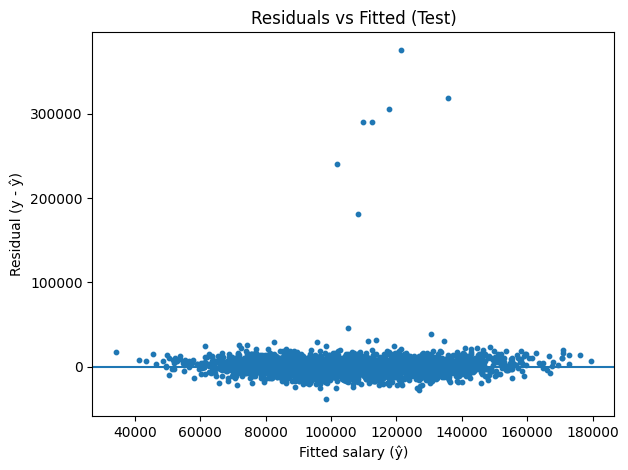

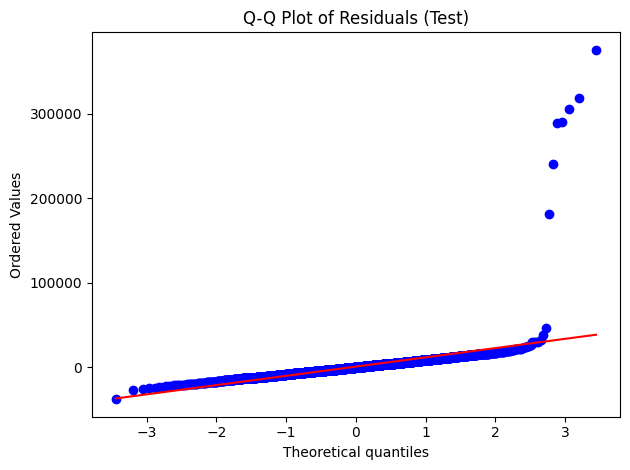

In [17]:
resid = y_test.values - y_pred
fit = y_pred

# Residuals vs fitted
plt.figure()
plt.scatter(fit, resid, s=10)
plt.axhline(0)
plt.xlabel("Fitted salary (ŷ)")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals vs Fitted (Test)")
plt.tight_layout()
plt.show()

# Q-Q plot
plt.figure()
stats.probplot(resid, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (Test)")
plt.tight_layout()
plt.show()


In [18]:
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = y_pred
test_df["resid"] = test_df["y_true"] - test_df["y_pred"]

t = np.percentile(test_df["y_true"], 75)
print("High-salary threshold (t):", t)

def group_fairness(df, group_col="gender", threshold=t):
    out = []
    for g, sub in df.groupby(group_col):
        y_true = sub["y_true"].values
        y_pred = sub["y_pred"].values
        resid = sub["resid"].values
        
        sel_pred = np.mean(y_pred >= threshold)
        sel_true = np.mean(y_true >= threshold)

        tp_mask = y_true >= threshold
        tn_mask = y_true < threshold
        
        tpr = np.mean((y_pred[tp_mask] >= threshold)) if tp_mask.sum() > 0 else np.nan
        fpr = np.mean((y_pred[tn_mask] >= threshold)) if tn_mask.sum() > 0 else np.nan

        out.append({
            "group": g,
            "n": len(sub),
            "mean_pred": np.mean(y_pred),
            "mean_true": np.mean(y_true),
            "mae": np.mean(np.abs(resid)),
            "mean_resid": np.mean(resid),
            "selection_rate_pred": sel_pred,
            "selection_rate_true": sel_true,
            "TPR": tpr,
            "FPR": fpr
        })
    return pd.DataFrame(out)

gm = group_fairness(test_df, "gender", t)
display(gm)


High-salary threshold (t): 121254.655


,group,n,mean_pred,mean_true,mae,mean_resid,selection_rate_pred,selection_rate_true,TPR,FPR
0,Female,1019,102450.958293,103291.293964,7544.467850,840.335671,0.207066,0.206084,0.847619,0.040791
1,Male,1338,108314.407273,108887.080801,7657.342121,572.673528,0.284753,0.285501,0.842932,0.061715
2,Other,43,99994.454826,100718.396279,6622.418585,723.941453,0.162791,0.186047,0.875000,0.000000


In [19]:
def pairwise_metrics(gm, ref="Male", comp="Female"):
    r = gm[gm["group"]==ref].iloc[0]
    c = gm[gm["group"]==comp].iloc[0]
    return pd.Series({
        "comparison": f"{comp} vs {ref}",
        "mean_pred_diff": c["mean_pred"] - r["mean_pred"],
        "mae_diff": c["mae"] - r["mae"],
        "DPD": c["selection_rate_pred"] - r["selection_rate_pred"],
        "EOD": c["TPR"] - r["TPR"],
        "PredictiveEquality_FPR_Diff": c["FPR"] - r["FPR"],
        "DIR": c["selection_rate_pred"] / r["selection_rate_pred"] if r["selection_rate_pred"]>0 else np.nan
    })

pm_f = pairwise_metrics(gm, "Male", "Female")
pm_o = pairwise_metrics(gm, "Male", "Other")

display(pd.DataFrame([pm_f, pm_o]))


,comparison,mean_pred_diff,mae_diff,DPD,EOD,PredictiveEquality_FPR_Diff,DIR
0,Female vs Male,-5863.448980,-112.874270,-0.077688,0.004687,-0.020924,0.727176
1,Other vs Male,-8319.952447,-1034.923535,-0.121963,0.032068,-0.061715,0.571690


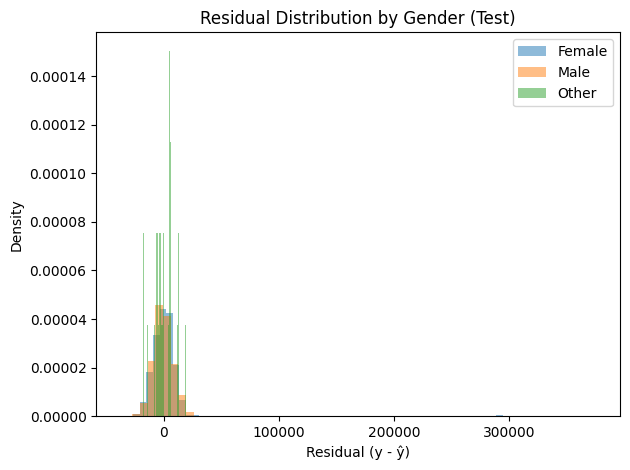

In [20]:
plt.figure()
for g in gm["group"].tolist():
    vals = test_df.loc[test_df["gender"]==g, "resid"].values
    plt.hist(vals, bins=60, alpha=0.5, density=True, label=g)
plt.legend()
plt.xlabel("Residual (y - ŷ)")
plt.ylabel("Density")
plt.title("Residual Distribution by Gender (Test)")
plt.tight_layout()
plt.show()


In [21]:
male_res = test_df.loc[test_df["gender"]=="Male", "resid"].values
female_res = test_df.loc[test_df["gender"]=="Female", "resid"].values
other_res = test_df.loc[test_df["gender"]=="Other", "resid"].values

# Welch t-tests
t_mf = stats.ttest_ind(male_res, female_res, equal_var=False)
t_mo = stats.ttest_ind(male_res, other_res, equal_var=False)

print("Welch t-test Male vs Female:", t_mf)
print("Welch t-test Male vs Other :", t_mo)


Welch t-test Male vs Female: TtestResult(statistic=-0.3568236985973095, pvalue=0.7212582278350166, df=2186.338952062831)
Welch t-test Male vs Other : TtestResult(statistic=-0.11180092598062402, pvalue=0.911382948141922, df=55.73200620860749)


In [22]:
bias_table = test_df.groupby("gender")["resid"].mean().reset_index().rename(columns={"resid":"mean_residual"})
display(bias_table)

# Interpretation rule:
# mean_residual > 0 => underprediction (y > ŷ)
# mean_residual < 0 => overprediction (y < ŷ)


,gender,mean_residual
0,Female,840.335671
1,Male,572.673528
2,Other,723.941453


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


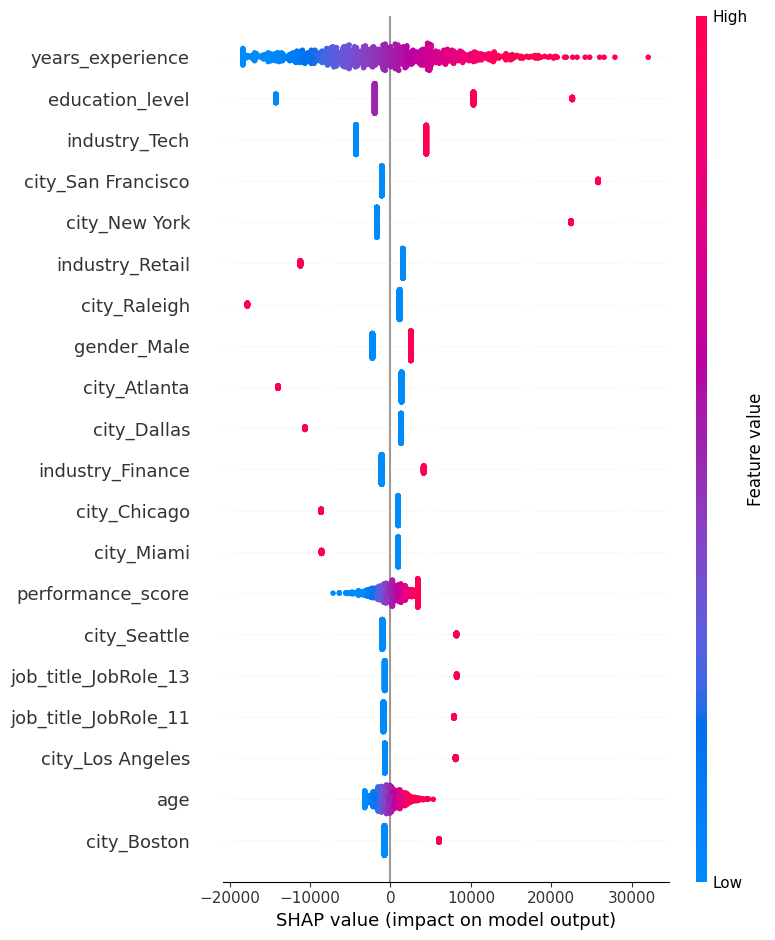

In [28]:
import shap

# Use a sample to make it fast
X_proc = preprocess.fit_transform(X)
X_proc_df = pd.DataFrame(X_proc, columns=feature_names)

lin_reg = LinearRegression().fit(X_proc, y)

explainer = shap.LinearExplainer(lin_reg, X_proc_df, feature_perturbation="interventional")
shap_values = explainer(X_proc_df.sample(1000, random_state=42))

shap.summary_plot(shap_values, X_proc_df.sample(1000, random_state=42))
